# **Salary Prediction using Simple Linear Regression**

### **Import Libraries**

In [ ]:
import numpy as np # used to perform mathematical operations
import pandas as pd # used to manipulate the dataframe
import matplotlib.pyplot as plt # used to show plot(graph)

from sklearn.model_selection import train_test_split # used to split the dataset into train and test dataset
from sklearn.linear_model import LinearRegression # linear regression model class used to predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # used to get prediction score

### **Load Dataset**

In [2]:
# loading the dataset using pandas
dataset_path = 'salary_data.csv'
df = pd.read_csv(dataset_path)

### **Explore Dataset**

In [3]:
print("Displaying the first 12 rows of the Dataframe: ")
df.head(12)

Displaying the first 12 rows of the Dataframe: 


,YearsExperience,Salary
0,0.1,30411.67
1,0.1,31951.57
2,0.1,32234.21
3,0.1,32549.03
4,0.1,31455.72
5,0.2,32700.62
6,0.2,32013.14
7,0.2,30394.37
8,0.2,32069.49
9,0.2,31580.30


In [4]:
print("Displaying the last 9 rows of the Dataframe: ")
df.tail(12)

Displaying the last 9 rows of the Dataframe: 


,YearsExperience,Salary
1188,19.8,119246.97
1189,19.8,118185.73
1190,19.8,118703.23
1191,19.8,117911.37
1192,19.8,117647.48
1193,19.8,120644.94
1194,19.9,119342.32
1195,19.9,117569.97
1196,19.9,120628.43
1197,19.9,120264.54


In [5]:
print("Displying the Shape of the Dataframe: ")
df.shape # this 'shape' returns a tuple and display no. of rows and no. of columns

Displying the Shape of the Dataframe: 


(1200, 2)

In [6]:
print("Displaying the all columns in the Dataframe: ")
df.columns # this columns return all columns in dataset

Displaying the all columns in the Dataframe: 


Index(['YearsExperience', 'Salary'], dtype='str')

In [7]:
print("Displaying the Information in the Dataframe: ")
df.info() # Display the Dataframe summary,colums, datatype and non-null values, memory useage

Displaying the Information in the Dataframe: 
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  1200 non-null   float64
 1   Salary           1200 non-null   float64
dtypes: float64(2)
memory usage: 18.9 KB


In [8]:
print("Displaying the null value sum in the Dataframe: ")
df.isnull().sum() # Display the columns null value count

Displaying the null value sum in the Dataframe: 


YearsExperience    0
Salary             0
dtype: int64

In [9]:
print("Displaying the Statistical Summary: ")
df.describe() # it return count, mean, min, max  and more 

Displaying the Statistical Summary: 


,YearsExperience,Salary
count,1200.000000,1200.000000
mean,9.981250,74985.011058
std,5.891846,26540.824771
min,0.100000,29456.180000
25%,4.800000,51309.855000
50%,10.200000,76076.680000
75%,15.125000,98341.232500
max,20.000000,121619.560000


### **Feature and Target**

In [10]:
X = df[['YearsExperience']]
y = df['Salary']

### **Visualize Dataset**

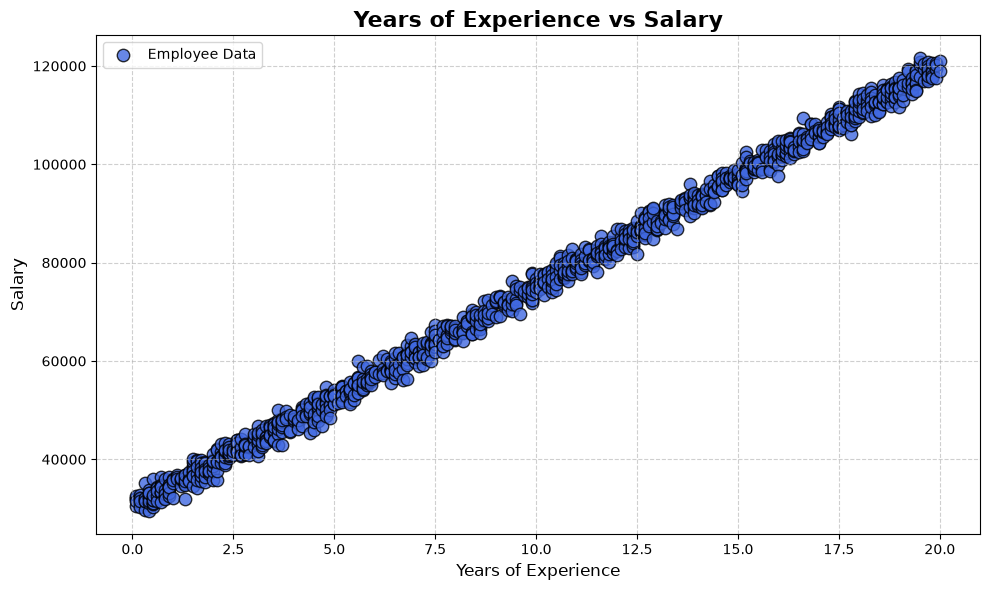

In [11]:
# Create a figure with a custom size
plt.figure(figsize=(10, 6))

# Plot the data points
plt.scatter(
    X,
    y,
    color="royalblue",# Marker color
    edgecolors="black",# Border color
    s=80,# Marker size
    alpha=0.8,# Transparency
    marker="o",# Marker style
    label="Employee Data"
)

# Set the title and axis labels
plt.title("Years of Experience vs Salary", fontsize=16, fontweight="bold")
plt.xlabel("Years of Experience", fontsize=12)
plt.ylabel("Salary", fontsize=12)

# Display grid lines
plt.grid(True, linestyle="--", alpha=0.6)

# Display legend
plt.legend()

# Automatically adjust the layout
plt.tight_layout()

# Display the plot
plt.show()

### **Split Dataset**

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [13]:
print("="*60)
print("Training and Testing Dataset Shapes: ")
print("="*60)

print(f"{'X_train Shape':<25}: {X_train.shape}")
print(f"{'X_test Shape':<25}: {X_test.shape}")
print(f"{'y_train Shape':<25}: {y_train.shape}")
print(f"{'y_test Shape':<25}: {y_test.shape}")

Training and Testing Dataset Shapes: 
X_train Shape            : (960, 1)
X_test Shape             : (240, 1)
y_train Shape            : (960,)
y_test Shape             : (240,)


### **Train Model**

In [14]:
model = LinearRegression() # creating a instance of the linear regression model

model.fit(X_train, y_train) #train the model using training dataset using fit() and fit() learns the relationship between X and y

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4496.94]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['YearsExperience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,3.015e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


### **Get Slope & Intercept**

In [15]:
slope = model.coef_[0]
intercept = model.intercept_

print("=" * 60)
print("          SIMPLE LINEAR REGRESSION MODEL")
print("=" * 60)

print(f"Slope (m)              : {slope:.4f}")
print(f"Intercept (c)          : {intercept:.4f}")

print("Best-Fit Regression Equation")
print("-" * 60)
print(f"Salary = ({slope:.4f} × Years_of_Experience) + ({intercept:.4f})")

print("=" * 60)

          SIMPLE LINEAR REGRESSION MODEL
Slope (m)              : 4496.9412
Intercept (c)          : 30153.2768
Best-Fit Regression Equation
------------------------------------------------------------
Salary = (4496.9412 × Years_of_Experience) + (30153.2768)


### **Make Predictions**

In [16]:
y_pred = model.predict(X_test)

In [17]:
comparison = pd.DataFrame({
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred
})
comparison.head(12)

,Actual Salary,Predicted Salary
0,119611.26,118743.018298
1,95643.84,95358.924099
2,38476.35,37348.382719
3,60892.48,62081.559276
4,34858.13,34200.523885
5,113142.51,114695.771225
6,53954.46,53537.371011
7,103562.21,103903.112364
8,56095.15,60282.782799
9,92016.16,94459.535860


### **Predict New Employee Salary**

In [18]:
experiance = float(input("Enter the years of Experiance: "))

predected_salary = model.predict([[experiance]])

print("="*60)
print("              Salary Prediction Result")
print("="*60)

print(f"Years of Experiance: {experiance:.1f}")
print(f"Predicted Salary   : {predected_salary[0]:.2f}")
print("="*60)

              Salary Prediction Result
Years of Experiance: 10.0
Predicted Salary   : 75122.69


c:\Users\boddu\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### **Plot Regression Line**

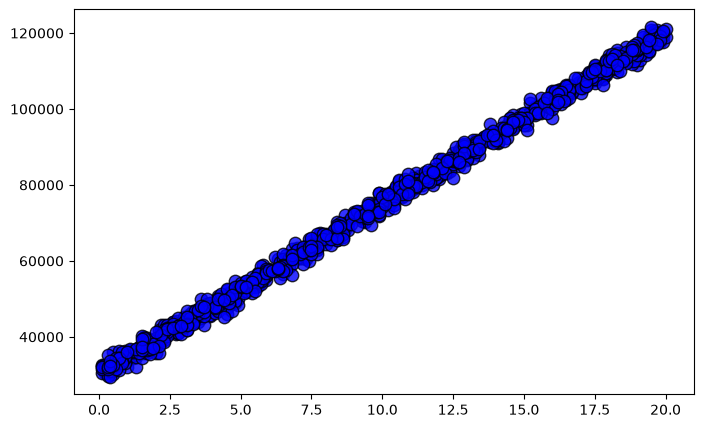

In [19]:
plt.figure(figsize=(8,5))
plt.scatter(
    X_train,
    y_train,
    color='blue',
    edgecolors='black',
    s=80,
    alpha=0.8,
    label='Training Data'
)

C:\Users\boddu\AppData\Local\Temp\ipykernel_21048\2788751572.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(


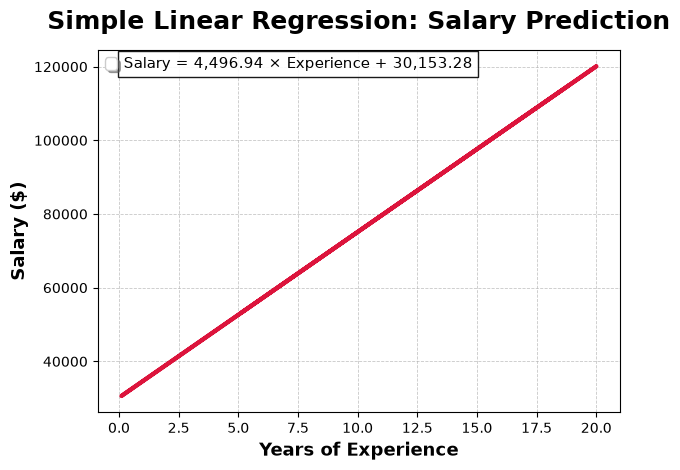

In [20]:
y_train_pred = model.predict(X_train)

plt.plot(
    X_train,
    y_train_pred,
    color="crimson",
    linewidth=3,
)

plt.title(
    "Simple Linear Regression: Salary Prediction",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Years of Experience",
    fontsize=13,
    fontweight="bold"
)

plt.ylabel(
    "Salary ($)",
    fontsize=13,
    fontweight="bold"
)

plt.text(
    0.05,
    0.95,
    f"Salary = {model.coef_[0]:,.2f} × Experience + {model.intercept_:,.2f}",
    transform=plt.gca().transAxes,
    fontsize=11,
    bbox=dict(
        facecolor="white",
        edgecolor="black",
        alpha=0.9
    )
)

plt.grid(
    linestyle="--",
    linewidth=0.6,
    alpha=0.7
)

plt.legend(
    fontsize=11,
    loc="upper left",
    frameon=True,
    shadow=True
)

plt.tight_layout()
plt.show()

### **MODEL EVALUATION**

In [21]:
# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_test, y_pred)

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)

# Calculate the R² Score (Coefficient of Determination)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("           LINEAR REGRESSION MODEL EVALUATION")
print("=" * 60)

print(f"{'Mean Absolute Error (MAE)':40}: {mae:10.2f}")
print(f"{'Mean Squared Error (MSE)':40}: {mse:10.2f}")
print(f"{'Root Mean Squared Error (RMSE)':40}: {rmse:10.2f}")
print(f"{'R² Score (Coefficient of Determination)':40}: {r2:10.4f}")

print("=" * 60)

           LINEAR REGRESSION MODEL EVALUATION
Mean Absolute Error (MAE)               :    1172.39
Mean Squared Error (MSE)                : 2273821.07
Root Mean Squared Error (RMSE)          :    1507.92
R² Score (Coefficient of Determination) :     0.9967


### **Visualize Actual vs Predicted Salary**

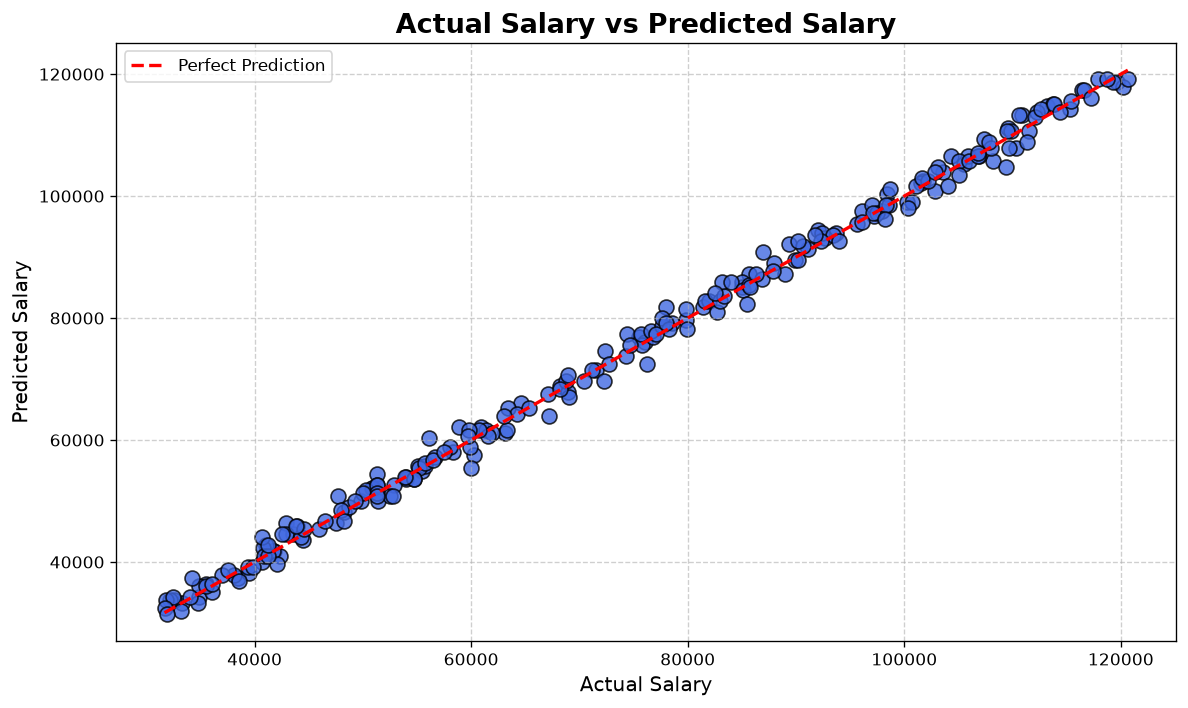

In [22]:
plt.figure(figsize=(10, 6), dpi=120)

# Scatter plot of actual vs predicted values
plt.scatter(
    y_test,
    y_pred,
    color="royalblue",
    edgecolor="black",
    s=80,
    alpha=0.8
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    "Actual Salary vs Predicted Salary",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Actual Salary", fontsize=12)
plt.ylabel("Predicted Salary", fontsize=12)

plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()

plt.show()

### **Residual Plot**

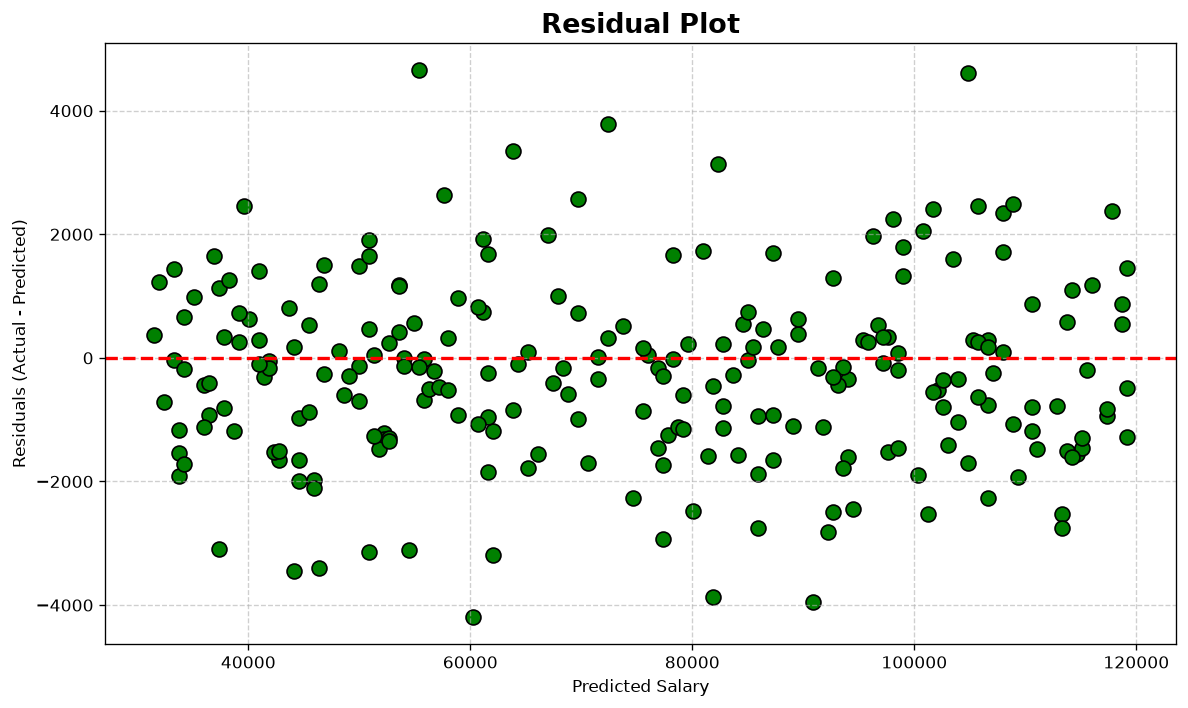

In [23]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6), dpi=120)

plt.scatter(
    y_pred,
    residuals,
    color="green",
    edgecolor="black",
    s=80
)

# Horizontal line at zero error
plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.title(
    "Residual Plot",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Salary")
plt.ylabel("Residuals (Actual - Predicted)")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

### **Compare Actual and Predicted Values**

In [24]:
results = pd.DataFrame({
    "Years of Experience": X_test.iloc[:, 0],
    "Actual Salary": y_test.values,
    "Predicted Salary": y_pred,
    "Residual": y_test.values - y_pred,
    "Absolute Error": np.abs(y_test.values - y_pred)
})

results = results.sort_values(by="Years of Experience")

results.head(12)

,Years of Experience,Actual Salary,Predicted Salary,Residual,Absolute Error
10,0.3,31869.73,31502.359169,367.370831,367.370831
23,0.4,33178.73,31952.053288,1226.676712,1226.676712
31,0.5,31681.31,32401.747408,-720.437408,720.437408
44,0.7,33273.66,33301.135646,-27.475646,27.475646
43,0.7,34734.09,33301.135646,1432.954354,1432.954354
51,0.8,32218.99,33750.829765,-1531.839765,1531.839765
54,0.8,31845.12,33750.829765,-1905.709765,1905.709765
49,0.8,32587.23,33750.829765,-1163.599765,1163.599765
58,0.9,34858.13,34200.523885,657.606115,657.606115
59,0.9,34021.11,34200.523885,-179.413885,179.413885


In [25]:
print("=" * 60)
print("              SIMPLE LINEAR REGRESSION MODEL SUMMARY")
print("=" * 60)

print(f"{'Algorithm':<30}: Simple Linear Regression")
print(f"{'Training Samples':<30}: {len(X_train)}")
print(f"{'Testing Samples':<30}: {len(X_test)}")
print(f"{'Input Feature':<30}: Years of Experience")
print(f"{'Target Variable':<30}: Salary")

print("-" * 60)

print(f"{'Slope (Coefficient)':<30}: {model.coef_[0]:.4f}")
print(f"{'Intercept':<30}: {model.intercept_:.4f}")

print("-" * 60)

print(f"{'MAE':<30}: {mae:.2f}")
print(f"{'MSE':<30}: {mse:.2f}")
print(f"{'RMSE':<30}: {rmse:.2f}")
print(f"{'R² Score':<30}: {r2*100:.2f}%")

print("=" * 60)

              SIMPLE LINEAR REGRESSION MODEL SUMMARY
Algorithm                     : Simple Linear Regression
Training Samples              : 960
Testing Samples               : 240
Input Feature                 : Years of Experience
Target Variable               : Salary
------------------------------------------------------------
Slope (Coefficient)           : 4496.9412
Intercept                     : 30153.2768
------------------------------------------------------------
MAE                           : 1172.39
MSE                           : 2273821.07
RMSE                          : 1507.92
R² Score                      : 99.67%
